**PROJECT DESCRIPTION**

A company that sells food products through a mobile application wants to understand user behavior during the purchase process.

---

**Research Objectives**

- Build an event funnel and identify the stages where users most frequently drop off  
- Calculate the overall conversion rate from app entry to successful payment  
- Validate the correctness of the A/A test by identifying whether there are statistically significant differences between the two control groups  
- Compare the experimental group with the control groups for each key user action  
- Evaluate the statistical significance of differences (including multiple testing correction)  
- Provide conclusions and recommendations based on the A/A/B experiment results, including whether to implement the new font in the app interface  

---

**Data Description**

Each record in the log represents a user action (event):

- EventName — event name  
- DeviceIDHash — unique user identifier  
- EventTimestamp — event timestamp  
- ExpId — experiment group ID:  
  - 246 and 247 — control groups  
  - 248 — experimental group  

---

**Project Plan**

- [Step 1. Load data and review general information](#data_section1)  

- [Step 2. Data preprocessing](#data_section2)  

- [Step 3. Data exploration and validation](#data_section3)  

- [Step 4. Event funnel analysis](#data_section4)  

- [Step 5. Experiment analysis](#data_section5)  

- [Conclusions and recommendations](#data_section6)  

<a id="data_section1"></a>
## Шаг 1. Открытие файла с данными и изучение общей информации

### Импорт библиотек

In [1]:
# Импорт стандартных библиотек для работы с датами и предупреждениями
from datetime import datetime, timedelta
import datetime as dt
import warnings

# Импорт библиотек для анализа и обработки данных
import pandas as pd
import numpy as np
import scipy.stats as stats
from pandas.plotting import register_matplotlib_converters
from statsmodels.stats.proportion import proportions_ztest

# Импорт библиотек для визуализации
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

### Загрузка файлов

In [2]:
#загрузим данные из локальных файлов, а если они не доступны 
#(например, если скрипт выполняется в другой среде или нет доступа к локальным файлам), 
#он загружает их из удалённых URL-адресов
# чтобы данные загрузились таблицей, используем sep='\t'
try:
    data = pd.read_csv('/datasets/logs_exp.csv', sep='\t')
except:
    data = pd.read_csv('https://code.s3.yandex.net//datasets/logs_exp.csv', sep='\t')


### Изучение общей информации о датафрейме

In [3]:
# выведем на экран первые 5 строчек и общую информацию по датафреймам data
display(data.head())
data.info()

,EventName,DeviceIDHash,EventTimestamp,ExpId
0,MainScreenAppear,4575588528974610257,1564029816,246
1,MainScreenAppear,7416695313311560658,1564053102,246
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248
3,CartScreenAppear,3518123091307005509,1564054127,248
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   EventName       244126 non-null  object
 1   DeviceIDHash    244126 non-null  int64 
 2   EventTimestamp  244126 non-null  int64 
 3   ExpId           244126 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 7.5+ MB


**ВЫВОДЫ И РЕКОМЕНДАЦИИ**
- Общие характеристики датасета:
   - Размер таблицы: 244 126 строк × 4 столбца
   - Типы данных:
        - EventName — категориальный текст (object), пригоден для группировок.
        - Остальные — целые числа (int64), пригодны для агрегаций, фильтрации и вычислений.
   - Пропусков нет — все значения заполнены (Non-Null Count = 244126 по всем столбцам).
- EventTimestamp - нужно будет преобразовать в формат даты/времени (datetime) для анализа.
- следует преобразовать названия столбцов к нижнему регистру и с нижним подчеркиванием

<a id="data_section2"></a>
## Шаг 2. Подготовка данных

- Замените названия столбцов на удобные для вас; 
- Проверьте пропуски и типы данных. Откорректируйте, если нужно;
- Добавьте столбец даты и времени, а также отдельный столбец дат;

#### Преобразование названий столбцов

In [4]:
# Переименование столбцов на более удобные и проверим - выведем первые 5 строчек
data = data.rename(columns={
    'EventName': 'event',
    'DeviceIDHash': 'user_id',
    'EventTimestamp': 'timestamp',
    'ExpId': 'group'
})
display(data.head())

,event,user_id,timestamp,group
0,MainScreenAppear,4575588528974610257,1564029816,246
1,MainScreenAppear,7416695313311560658,1564053102,246
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248
3,CartScreenAppear,3518123091307005509,1564054127,248
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248


**ВЫВОДЫ**
- Названия столбцов преобразовались 

#### Проверка пропусков и типов данных

In [5]:
print(data.info())
print("\nПропуски в данных:\n", data.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   event      244126 non-null  object
 1   user_id    244126 non-null  int64 
 2   timestamp  244126 non-null  int64 
 3   group      244126 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 7.5+ MB
None

Пропуски в данных:
 event        0
user_id      0
timestamp    0
group        0
dtype: int64


**ВЫВОДЫ**
- Типы данных:
  
        - event - object
        - user_id - int64 
        - timestamp - int64 
        - group - int64
  Необходимо преобразовать в формат даты столбец timestamp

- Пропусков в данных нет

#### Преобразование столбцов к типу даты

In [6]:
# Преобразуем timestamp в datetime
data['event_time'] = pd.to_datetime(data['timestamp'], unit='s')

# Отдельный столбец только с датой
data['event_date'] = pd.to_datetime(data['event_time']).dt.normalize()

#отдельный столбец с месяцами
data['event_month'] = data['event_time'].dt.to_period('M').dt.to_timestamp()

# проверим преобразовались ли данные
display(data.dtypes)
display(data.head())

event                  object
user_id                 int64
timestamp               int64
group                   int64
event_time     datetime64[ns]
event_date     datetime64[ns]
event_month    datetime64[ns]
dtype: object

,event,user_id,timestamp,group,event_time,event_date,event_month
0,MainScreenAppear,4575588528974610257,1564029816,246,2019-07-25 04:43:36,2019-07-25,2019-07-01
1,MainScreenAppear,7416695313311560658,1564053102,246,2019-07-25 11:11:42,2019-07-25,2019-07-01
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248,2019-07-25 11:28:47,2019-07-25,2019-07-01
3,CartScreenAppear,3518123091307005509,1564054127,248,2019-07-25 11:28:47,2019-07-25,2019-07-01
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248,2019-07-25 11:48:42,2019-07-25,2019-07-01


**ВЫВОДЫ**
- Данные преобразовались в формат даты datetime64[ns] и добавились новые столбцы для дальнейшего анализа

#### Проверим дубликаты

In [7]:
#найдем есть ли дубликаты
data.duplicated().sum()

413

In [8]:
#удалим дубликаты
data = data.drop_duplicates()
display(data.duplicated().sum())

0

**ВЫВОДЫ**
- 413 полных дубликатов — произвели их удаление

#### Проверка на наличие повторяющихся пользователей в группах

Проверка на повторяющихся пользователей в разных группах важна, особенно для A / A/B-тестов — один и тот же пользователь не должен попадать в разные группы.

In [9]:
# разделим пользователей на группы
users_246 = set(data[data['group'] == 246]['user_id'])
users_247 = set(data[data['group'] == 247]['user_id'])
users_248 = set(data[data['group'] == 248]['user_id'])

# Пересечения между группами
duplicates_246_247 = users_246 & users_247
duplicates_246_248 = users_246 & users_248
duplicates_247_248 = users_247 & users_248

# Объединённое множество всех дубликатов
duplicate_users = duplicates_246_247 | duplicates_246_248 | duplicates_247_248

print(f'Пользователи в группах 246 и 247: {len(duplicates_246_247)}')
print(f'Пользователи в группах 246 и 248: {len(duplicates_246_248)}')
print(f'Пользователи в группах 247 и 248: {len(duplicates_247_248)}')
print(f'Всего пользователей в двух и более группах: {len(duplicate_users)}')

Пользователи в группах 246 и 247: 0
Пользователи в группах 246 и 248: 0
Пользователи в группах 247 и 248: 0
Всего пользователей в двух и более группах: 0


**ВЫВОДЫ**
- Пользователи в группах не пересекаются

<a id="data_section3"></a>
## Шаг 3. Изучение и проверка данных

Вопросы для изучения:
- Сколько всего событий в логе?
- Сколько всего пользователей в логе?
- Сколько в среднем событий приходится на пользователя?
- Данными за какой период вы располагаете? Найдите максимальную и минимальную дату. Изучите, как меняется количество данных: постройте столбчатую диаграмму, которая отобразит количество событий в зависимости от времени в разрезе групп. Можно ли быть уверенным, что у вас одинаково полные данные за весь период? Технически в логи новых дней по некоторым пользователям могут «доезжать» события из прошлого — это может «перекашивать данные». Определите, с какого момента данные полные и отбросьте более старые. Данными за какой период времени вы располагаете на самом деле?
- Много ли событий и пользователей вы потеряли, отбросив старые данные?
- Проверьте, что у вас есть пользователи из всех трёх экспериментальных групп.

#### Количество событий в логе

In [10]:
total_events = len(data)
print(f'Всего событий в логе: {total_events}')

Всего событий в логе: 243713


**ВЫВОДЫ**
- 243 713 событий в логе

#### Количество пользователей в логе

In [11]:
unique_users = data['user_id'].nunique()
print(f'Уникальных пользователей: {unique_users}')


Уникальных пользователей: 7551


**ВЫВОДЫ**
- Уникальных пользователей: 7551

#### Среднее количество событий на пользователя

In [12]:
avg_events_per_user = total_events / unique_users
print(f'Среднее количество событий на пользователя: {avg_events_per_user:.2f}')

Среднее количество событий на пользователя: 32.28


**ВЫВОДЫ**
- Среднее количество событий на пользователя: 32.28

#### Изучение временного интервала и полнота данных

##### Найдем минимальную и максимальную даты

In [13]:
min_date = data['event_time'].min()
max_date = data['event_time'].max()
print(f'Период данных: от {min_date.date()} до {max_date.date()}')

Период данных: от 2019-07-25 до 2019-08-07


**ВЫВОДЫ**
- В таблице представлены данные запериод с 25 июля 2019 до 7 августа 2019

##### Рассмотрим как меняется количество событий во времени 

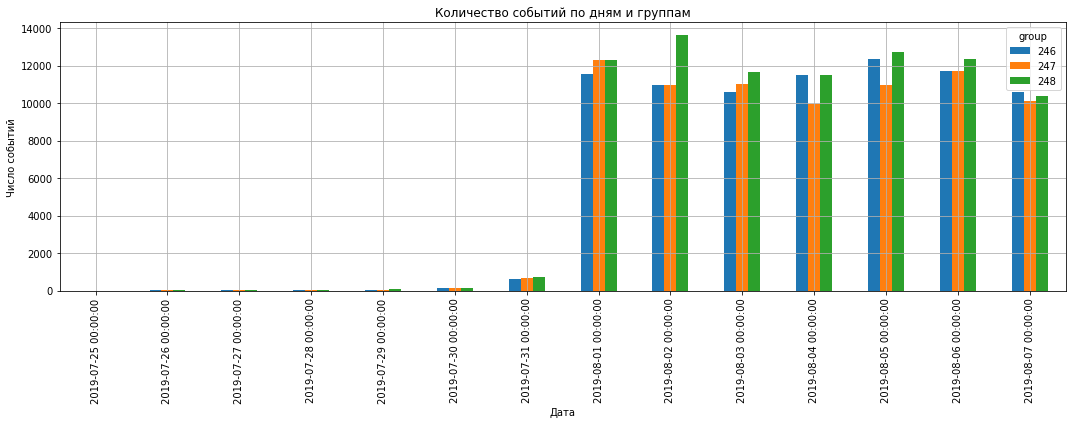

In [14]:
# Считаем количество событий по дате и группе
events_by_date = data.groupby(['event_date', 'group'])['event'].count().unstack()

# Строим столбчатую диаграмму
events_by_date.plot(kind='bar', figsize=(15, 6))
plt.title('Количество событий по дням и группам')
plt.xlabel('Дата')
plt.ylabel('Число событий')
plt.grid(True)
plt.tight_layout()
plt.show()

**ВЫВОДЫ И РЕКОМЕНДАЦИИ**
- Неполные данные до 1 августа 2019 года:
   - Событий очень мало до этой даты — особенно с 25 по 31 июля.
   - Это может быть связано с задержкой логов или техническими ограничениями.
- Полные и стабильные данные с 1 августа 2019 года:
   - Начиная с 1 августа, объёмы событий стабильны и сопоставимы между группами.
   - Все три группы (246, 247, 248) представлены равномерно.

- Для анализа стоит использовать данные, начиная с 1 августа 2019. Это позволит избежать искажений из-за неполных или «доезжающих» событий.

Отфильтруем данные - оставим только данные с 1 августа 2019

In [15]:
filtered_data = data[data['event_time'] >= '2019-08-01']

#проверим данные по датам в таблице
min_date = filtered_data['event_time'].min()
max_date = filtered_data['event_time'].max()
print(f'Период данных: от {min_date.date()} до {max_date.date()}')

Период данных: от 2019-08-01 до 2019-08-07


**ВЫВОДЫ**
- Данные отфильтровались в новой таблице filtered_data и стали теперь с 1 по 7 августа 2019

##### Рассмотрим сколько данных потеряно при отсечении

In [16]:
# Общее количество событий и пользователей
total_events_filtered = filtered_data.shape[0]
total_users_filtered = filtered_data['user_id'].nunique()

lost_events = data.shape[0] - total_events_filtered
lost_users = data['user_id'].nunique() - total_users_filtered

print(f'Потеряно событий: {lost_events}')
print(f'Потеряно пользователей: {lost_users}')


Потеряно событий: 2826
Потеряно пользователей: 17


**ВЫВОДЫ**
- После удаления данных до 1 августа 2019:
    - Потеряно событий: 2 826
    - Потеряно пользователей: 17
- Потери незначительны, можно уверенно использовать данные с 1 августа как репрезентативные.
- График после этой даты показывает стабильное распределение событий по группам, без перекосов.
- Такое решение помогает избежать искажения анализа из-за неполных логов в начале периода.

##### Изучим, есть ли пользователи из всех трёх групп

In [17]:
print('Уникальные значения в group:', filtered_data['group'].unique())
print('Количество пользователей по группам:')
print(filtered_data.groupby('group')['user_id'].nunique())


Уникальные значения в group: [246 247 248]
Количество пользователей по группам:
group
246    2484
247    2513
248    2537
Name: user_id, dtype: int64


**ВЫВОДЫ**
- Все группы представлены, распределение пользователей примерно равномерное, что даёт хорошую базу для сравнения при A/ A/B-тесте.
- Можно уверенно двигаться дальше с анализом поведения пользователей по группам.

<a id="data_section4"></a>
## Шаг 4. Изучение воронки событий

Вопросы для изучения:
- Посмотрите, какие события есть в логах, как часто они встречаются. Отсортируйте события по частоте.
- Посчитайте, сколько пользователей совершали каждое из этих событий. Отсортируйте события по числу пользователей. Посчитайте долю пользователей, которые хоть раз совершали событие.
- Предположите, в каком порядке происходят события. Все ли они выстраиваются в последовательную цепочку? Их не нужно учитывать при расчёте воронки.
- По воронке событий посчитайте, какая доля пользователей проходит на следующий шаг воронки (от числа пользователей на предыдущем). То есть для последовательности событий A → B → C посчитайте отношение числа пользователей с событием B к количеству пользователей с событием A, а также отношение числа пользователей с событием C к количеству пользователей с событием B.
- На каком шаге теряете больше всего пользователей?
- Какая доля пользователей доходит от первого события до оплаты?

##### Рассмотрим какие события есть в логах, как часто они встречаются

In [18]:
# Рассмотрим какие события есть в логах, как часто они встречаются и отсортируем по частоте
event_counts = filtered_data['event'].value_counts()
print(event_counts)

MainScreenAppear           117328
OffersScreenAppear          46333
CartScreenAppear            42303
PaymentScreenSuccessful     33918
Tutorial                     1005
Name: event, dtype: int64


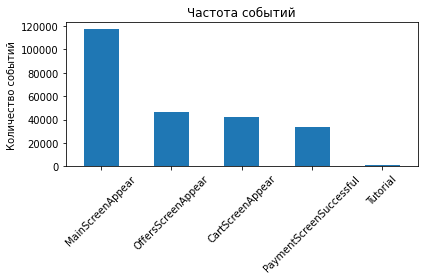

In [19]:
event_counts.plot(kind='bar', title='Частота событий')
plt.ylabel('Количество событий')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Выводы: 
- MainScreenAppear — самый частый экран:
   - Это первое и базовое взаимодействие — точка входа почти для всех пользователей.
   - Почти каждый пользователь начинает с этого шага.

- OffersScreenAppear → CartScreenAppear → PaymentScreenSuccessful:
   - Отображают воронку: просмотр предложений → добавление в корзину → успешная оплата.

- Видно, что на каждом шаге идёт постепенное снижение числа событий — нормальное явление в воронке.

- Tutorial — редкое событие: Лишь ~1 000 раз (всего ~1% от MainScreenAppear). Вероятно, это необязательное или устаревшее событие и его не стоит включать в основную воронку.

##### Рассмотрим, сколько пользователей совершали каждое из этих событий

In [20]:
# рассмотрим сколько пользователей совершали каждое из этих событий, отсортируем события по числу пользователей
unique_users_per_event = filtered_data.groupby('event')['user_id'].nunique().sort_values(ascending=False)
print(unique_users_per_event)

event
MainScreenAppear           7419
OffersScreenAppear         4593
CartScreenAppear           3734
PaymentScreenSuccessful    3539
Tutorial                    840
Name: user_id, dtype: int64


##### Посчитаем долю пользователей, которые хоть раз совершали событие

In [21]:
# посчитаем общее число пользователей
total_users = filtered_data['user_id'].nunique()

#Посчитакс долю пользователей, совершивших каждое событие
event_user_share = (unique_users_per_event / total_users).round(3)

#  Объединим всё в одну таблицу
event_analysis = pd.DataFrame({
    'Пользователи': unique_users_per_event,
    'Доля пользователей, которые хотя бы раз совершали событие': event_user_share
})
print(event_analysis)

                         Пользователи  \
event                                   
MainScreenAppear                 7419   
OffersScreenAppear               4593   
CartScreenAppear                 3734   
PaymentScreenSuccessful          3539   
Tutorial                          840   

                         Доля пользователей, которые хотя бы раз совершали событие  
event                                                                               
MainScreenAppear                                                     0.985          
OffersScreenAppear                                                   0.610          
CartScreenAppear                                                     0.496          
PaymentScreenSuccessful                                              0.470          
Tutorial                                                             0.111          


**ВЫВОДЫ**
-  MainScreenAppear — основной шаг:
    - 99% пользователей начали с экрана MainScreenAppear.
    - Это — точка входа почти для всех, как и ожидалось.

- OffersScreenAppear — первое снижение:
    - Только 61% пользователей дошли до просмотра предложений.
    - Здесь теряется почти 40% аудитории после главного экрана. Возможные причины: неинтересный первый экран или непонятный путь к офферам

- CartScreenAppear → PaymentScreenSuccessful — стабильный переход:
     - В корзину дошли 50% пользователей, до оплаты — 47%.
     - Это значит, что большинство пользователей, перешедших в корзину, завершают оплату, соответственно конверсия из корзины в оплату высокая.

- Tutorial — необязательный шаг:
      - Только 11% пользователей его проходили. Вероятно, это опциональное событие, которое не стоит учитывать в воронке.

- Есть смысл оптимизировать переход с главного экрана к предложениям, чтобы удержать больше пользователей в начале.

##### Предположите, в каком порядке происходят события. Все ли они выстраиваются в последовательную цепочку? Их не нужно учитывать при расчёте воронки.

Все основные события выстраиваются в последовательную воронку.

Предполагаемый логический порядок:

**MainScreenAppear → OffersScreenAppear → CartScreenAppear → PaymentScreenSuccessful**

- MainScreenAppear — точка входа, старт почти для всех.

- OffersScreenAppear — просмотр товаров/предложений.

- CartScreenAppear — добавление товаров в корзину.

- PaymentScreenSuccessful — завершение покупки.
  
- Tutorial прошли только 11% пользователей. Он встречается реже всех, и не связан с процессом покупки напрямую. Вывод: Tutorial — это вспомогательное или факультативное событие, Tutorial не стоит учитывать при построении воронки

##### По воронке событий посчитайте, какая доля пользователей проходит на следующий шаг воронки (от числа пользователей на предыдущем). То есть для последовательности событий A → B → C посчитайте отношение числа пользователей с событием B к количеству пользователей с событием A, а также отношение числа пользователей с событием C к количеству пользователей с событием B.

Просчитаем долю пользователей, которая проходит на следующий шаг, без Tutorial

In [22]:
# Определяем ключевые этапы воронки
funnel_steps = [
    'MainScreenAppear', 
    'OffersScreenAppear', 
    'CartScreenAppear', 
    'PaymentScreenSuccessful'
]

# Фильтруем данные: оставляем только события из воронки
funnel = filtered_data[filtered_data['event'].isin(funnel_steps)]

# Считаем уникальных пользователей на каждом этапе
funnel_users = (
    funnel
    .groupby('event')['user_id']
    .nunique()
    .reindex(funnel_steps)  # сохраняем нужный порядок
)

# Рассчитываем конверсию от предыдущего шага
conversion = funnel_users.pct_change()+1

# Формируем итоговую таблицу воронки
funnel_table = pd.DataFrame({
    'Пользователи': funnel_users,
    'Конверсия к предыдущему': (conversion * 100).round(1).astype(str) + '%'
})

# Выводим результат
print(funnel_table)


                         Пользователи Конверсия к предыдущему
event                                                        
MainScreenAppear                 7419                    nan%
OffersScreenAppear               4593                   61.9%
CartScreenAppear                 3734                   81.3%
PaymentScreenSuccessful          3539                   94.8%


**ВЫВОДЫ**
- Самое узкое место — первый шаг: после главного экрана только 62% пользователей переходят к предложениям. Потеря: 38% это основная точка для оптимизации.

- Стабильное поведение на следующих этапах:
     - Из перешедших к предложениям 81% доходят до корзины.
     - Из корзины 95% совершают оплату — это высокая конверсия, значит процесс покупки удобный.

- Положительный тренд внутри воронки: конверсии улучшаются с каждым шагом — те, кто прошёл дальше, почти не отваливаются.

##### На каком шаге теряете больше всего пользователей?

**ВЫВОДЫ**
- Самая низкая конверсия — между MainScreenAppear → OffersScreenAppear = 62%. То есть на этом шаге теряется ~38% пользователей.
- Больше всего пользователей теряется на первом шаге воронки  — при переходе с главного экрана к экрану предложений.
- Это может указывать на то, что: пользователи не находят путь к офферам, либо основной экран не мотивирует идти дальше.

##### Какая доля пользователей доходит от первого события до оплаты?

In [23]:
full_conversion = funnel_users['PaymentScreenSuccessful'] / funnel_users['MainScreenAppear']
print(f'Общая конверсия от входа до оплаты: {full_conversion:.1%}')

Общая конверсия от входа до оплаты: 47.7%


**ВЫВОДЫ**
- Почти половина пользователей (47.7%), начавших взаимодействие с приложением с главного экрана, доходят до успешной оплаты.
- Это говорит о высокой эффективности пользовательского пути и хорошем удержании на всех этапах воронки, за исключением первого шага.
- Основное "узкое место" — переход с главного экрана к предложениям. Если улучшить вовлечение на этом этапе, общая конверсия может вырасти ещё сильнее.

<a id="data_section5"></a>
## Шаг 5. Изучение результатов эксперимента


Вопросы для изучения:

- Сколько пользователей в каждой экспериментальной группе?
- Есть 2 контрольные группы для А/А-эксперимента, чтобы проверить корректность всех механизмов и расчётов. Проверьте, находят ли статистические критерии разницу между выборками 246 и 247.
- Выберите самое популярное событие. Посчитайте число пользователей, совершивших это событие в каждой из контрольных групп. Посчитайте долю пользователей, совершивших это событие. Проверьте, будет ли отличие между группами статистически достоверным. Проделайте то же самое для всех других событий (удобно обернуть проверку в отдельную функцию). Можно ли сказать, что разбиение на группы работает корректно?
- Аналогично поступите с группой с изменённым шрифтом. Сравните результаты с каждой из контрольных групп в отдельности по каждому событию. Сравните результаты с объединённой контрольной группой. Какие выводы из эксперимента можно сделать?
- Какой уровень значимости вы выбрали при проверке статистических гипотез выше? Посчитайте, сколько проверок статистических гипотез вы сделали. При уровне значимости 0.1 в 10% случаев можно ошибочно отклонить нулевую гипотезу при условии, что она верна. Какой уровень значимости стоит применить? Если вы хотите изменить его, проделайте предыдущие пункты и проверьте свои выводы.


##### Сколько пользователей в каждой экспериментальной группе?

In [24]:
users_per_group = filtered_data.groupby('group')['user_id'].nunique()
print(users_per_group)

group
246    2484
247    2513
248    2537
Name: user_id, dtype: int64


**ВЫВОДЫ**
- Группы сбалансированы — число пользователей в каждой группе примерно одинаковое.
- Максимальная разница — всего 20 пользователей между самой большой и самой маленькой группой.
- Это говорит о корректной рандомизации при разбиении на группы, что важно для достоверности результатов A/B/A-эксперимента.


##### Есть 2 контрольные группы для А/А-эксперимента, чтобы проверить корректность всех механизмов и расчётов. Проверьте, находят ли статистические критерии разницу между выборками 246 и 247

**Цель A/A-эксперимента:**
Проверить, корректно ли работает механизм сплитования пользователей на группы, и не вносит ли он искажений в результаты.
В A/A-тесте обе группы (246 и 247) должны быть идентичны по поведению, т.к. никаких изменений в продукте между ними нет.

Сформируем **гипотезы** для каждой воронки событий (MainScreenAppear, OffersScreenAppear, CartScreenAppear, PaymentScreenSuccessful): 
- Нулевая гипотеза (H₀):
Группы 246 и 247 статистически не отличаются друг от друга на каждом этапе пользовательской воронки.
Доли пользователей, совершающих ключевые действия (от первого экрана до оплаты), одинаковы в обеих группах.

- Альтернативная гипотеза (H₁):
Группы 246 и 247 отличаются хотя бы на одном из шагов воронки.
Есть статистически значимые различия в поведении пользователей между группами хотя бы на одном этапе.

Для проверки гипотез используем статистический тест о равенстве долей — Z-тест для пропорций (proportions_ztest), который проверяет, есть ли статистически значимая разница между долями двух групп, например: долей пользователей, которые совершили конкретное действие (например, оплату) в двух разных группах (246 и 247)

In [25]:
# фильтруем по ключевым воронкам
funnel_steps = ['MainScreenAppear', 'OffersScreenAppear', 'CartScreenAppear', 'PaymentScreenSuccessful']

# Общее количество пользователей в группах
n_246 = filtered_data.query('group == 246')['user_id'].nunique()
n_247 = filtered_data.query('group == 247')['user_id'].nunique()

# Расчёт p-value по каждому событию
for step in funnel_steps:
    users_246 = filtered_data.query('group == 246 and event == @step')['user_id'].nunique()
    users_247 = filtered_data.query('group == 247 and event == @step')['user_id'].nunique()
    
    stat, p = proportions_ztest([users_246, users_247], [n_246, n_247])
    
    print(f'{step}: p-value = {p:.4f}')


MainScreenAppear: p-value = 0.7571
OffersScreenAppear: p-value = 0.2481
CartScreenAppear: p-value = 0.2288
PaymentScreenSuccessful: p-value = 0.1146


**Вывод по A/A-тесту (группы 246 и 247):
- Для всех шагов воронки p-value выше уровня значимости 0.05:
  - MainScreenAppear: 0.7571
  - OffersScreenAppear: 0.2481
  - CartScreenAppear: 0.2288
  - PaymentScreenSuccessful: 0.1146
- Нет статистически значимых различий между двумя контрольными группами. Это говорит о том, что: рандомизация работает корректно и A/B-тест можно проводить — разделение на группы не вносит искажения

##### Выберите самое популярное событие. Посчитайте число пользователей, совершивших это событие в каждой из контрольных групп. Посчитайте долю пользователей, совершивших это событие. Проверьте, будет ли отличие между группами статистически достоверным. Проделайте то же самое для всех других событий (удобно обернуть проверку в отдельную функцию). Можно ли сказать, что разбиение на группы работает корректно?

Найдем самое популярное событие

In [26]:
# Находим самое популярное событие
top_event = filtered_data['event'].value_counts().idxmax()

Посчитаем долю пользователей, совершивших это событие.

In [27]:
# Считаем количество пользователей в группах
total_246 = filtered_data.query('group == 246')['user_id'].nunique()
total_247 = filtered_data.query('group == 247')['user_id'].nunique()

# Считаем пользователей, совершивших событие
users_246 = filtered_data.query('group == 246 and event == @top_event')['user_id'].nunique()
users_247 = filtered_data.query('group == 247 and event == @top_event')['user_id'].nunique()

# Доли
share_246 = users_246 / total_246
share_247 = users_247 / total_247

Проверим, будет ли отличие между группами статистически достоверным. Для этого сформулируем **гипотезы**: 

- Нулевая гипотеза (H₀):
Группы 246 и 247 статистически не отличаются друг от друга на самом популярном событии

- Альтернативная гипотеза (H₁):
Группы 246 и 247 отличаются

In [28]:
# Z-тест пропорций
stat, p = proportions_ztest([users_246, users_247], [total_246, total_247])

# Вывод результата
print(f"Самое популярное событие: {top_event}")
print(f"Группа 246 — пользователей: {users_246}, доля: {share_246:.3f}")
print(f"Группа 247 — пользователей: {users_247}, доля: {share_247:.3f}")
print(f"p-value: {p:.4f}")

if p < 0.05:
    print("Различия статистически значимы.")
else:
    print("Различия не являются статистически значимыми.")

Самое популярное событие: MainScreenAppear
Группа 246 — пользователей: 2450, доля: 0.986
Группа 247 — пользователей: 2476, доля: 0.985
p-value: 0.7571
Различия не являются статистически значимыми.


**ВЫВОДЫ**
- Самым популярным событием является MainScreenAppear
- Различий между группами 246 и 247 нет, так как p-value > 0.05

Сформируем **гипотезы** для каждой воронки событий (MainScreenAppear, OffersScreenAppear, CartScreenAppear, PaymentScreenSuccessful):

Нулевая гипотеза (H₀):
  - Доли пользователей, совершивших событие, одинаковы в группах 246 и 247
(т.е. статистически значимых различий нет)

Альтернативная гипотеза (H₁):
 - Есть статистически значимые различия между группами 246 и 247 по доле пользователей, совершивших событие


Создадим функцию для сравнения по событиям

In [29]:
def compare_event_across_groups(filtered_data, group1=246, group2=247):
    # Исключаем Tutorial
    events = [e for e in filtered_data['event'].unique() if e != 'Tutorial']
    results = []

    # Общее число пользователей в каждой группе
    total_1 = filtered_data[filtered_data['group'] == group1]['user_id'].nunique()
    total_2 = filtered_data[filtered_data['group'] == group2]['user_id'].nunique()

    for event in events:
        users_1 = filtered_data.query('group == @group1 and event == @event')['user_id'].nunique()
        users_2 = filtered_data.query('group == @group2 and event == @event')['user_id'].nunique()

        share_1 = users_1 / total_1
        share_2 = users_2 / total_2

        stat, p = proportions_ztest([users_1, users_2], [total_1, total_2])

        results.append({
            'Событие': event,
            f'Пользователи {group1}': users_1,
            f'Пользователи {group2}': users_2,
            f'Доля {group1}': round(share_1, 3),
            f'Доля {group2}': round(share_2, 3),
            'p-value': round(p, 4)
        })

    return pd.DataFrame(results).sort_values('p-value')

#Вызов функции
event_results = compare_event_across_groups(filtered_data)
display(event_results)


,Событие,Пользователи 246,Пользователи 247,Доля 246,Доля 247,p-value
3,PaymentScreenSuccessful,1200,1158,0.483,0.461,0.1146
2,CartScreenAppear,1266,1238,0.510,0.493,0.2288
1,OffersScreenAppear,1542,1520,0.621,0.605,0.2481
0,MainScreenAppear,2450,2476,0.986,0.985,0.7571


Сформируем выводы

In [30]:
print("ВЫВОДЫ")
for _, row in event_results.iterrows():
    print(
        f"*Событие: {row['Событие']}\n"
        f"  Доля группы 246: {row['Доля 246']:.3f}\n"
        f"  Доля группы 247: {row['Доля 247']:.3f}\n"
        f"  p-value: {row['p-value']:.4f}\n"
        f"  ➤ {'Не получилось отвергнуть нулевую гипотезу, нет оснований считать доли разными' if row['p-value'] >= 0.05 else 'Отвергаем нулевую гипотезу: между долями есть значимая разница'}\n"
    )


ВЫВОДЫ
*Событие: PaymentScreenSuccessful
  Доля группы 246: 0.483
  Доля группы 247: 0.461
  p-value: 0.1146
  ➤ Не получилось отвергнуть нулевую гипотезу, нет оснований считать доли разными

*Событие: CartScreenAppear
  Доля группы 246: 0.510
  Доля группы 247: 0.493
  p-value: 0.2288
  ➤ Не получилось отвергнуть нулевую гипотезу, нет оснований считать доли разными

*Событие: OffersScreenAppear
  Доля группы 246: 0.621
  Доля группы 247: 0.605
  p-value: 0.2481
  ➤ Не получилось отвергнуть нулевую гипотезу, нет оснований считать доли разными

*Событие: MainScreenAppear
  Доля группы 246: 0.986
  Доля группы 247: 0.985
  p-value: 0.7571
  ➤ Не получилось отвергнуть нулевую гипотезу, нет оснований считать доли разными



- По всем ключевым событиям (MainScreenAppear, OffersScreenAppear, CartScreenAppear, PaymentScreenSuccessful)
p-value > 0.05, то есть различий между группами нет.

- Доли пользователей, совершивших каждое из событий, практически совпадают между группами.

- Группы 246 и 247 эквивалентны, следовательно, A/B-тест с использованием этих групп можно считать надёжным и валидным.

##### Аналогично поступите с группой с изменённым шрифтом. Сравните результаты с каждой из контрольных групп в отдельности по каждому событию. Сравните результаты с объединённой контрольной группой. Какие выводы из эксперимента можно сделать?

Сформулируем **гипотезы**: 

Нулевая гипотеза (H₀):
 - Поведение пользователей в группе 248 (тестовая, с новым шрифтом) не отличается от поведения в контрольных группах (246 и 247) и их объединением. То есть, доли пользователей, совершивших каждое ключевое событие, одинаковы между группой 248 и каждой из контрольных групп и их объединением.

Альтернативная гипотеза (H₁):
- Группа 248 отличается от хотя бы одной из контрольных групп (246, 247 или объединённой) по доле пользователей, совершивших одно или несколько ключевых событий. То есть, есть статистически значимые различия в поведении пользователей.

Проведем z-тесты пропорций. Результаты и p-value представлены в таблице ниже.

In [31]:
from statsmodels.stats.proportion import proportions_ztest
import pandas as pd

# Список событий без Tutorial
events = [e for e in filtered_data['event'].unique() if e != 'Tutorial']

# Общее число пользователей
total_246 = filtered_data.query('group == 246')['user_id'].nunique()
total_247 = filtered_data.query('group == 247')['user_id'].nunique()
total_248 = filtered_data.query('group == 248')['user_id'].nunique()
control_data = filtered_data[filtered_data['group'].isin([246, 247])]
total_control = control_data['user_id'].nunique()

# Список для результатов
results = []

print("ВЫВОДЫ ПО СРАВНЕНИЮ ГРУПП 248 С КОНТРОЛЬНЫМИ\n")

for event in events:
    u_246 = filtered_data.query('group == 246 and event == @event')['user_id'].nunique()
    u_247 = filtered_data.query('group == 247 and event == @event')['user_id'].nunique()
    u_248 = filtered_data.query('group == 248 and event == @event')['user_id'].nunique()
    u_control = control_data.query('event == @event')['user_id'].nunique()

    share_248 = u_248 / total_248
    share_246 = u_246 / total_246
    share_247 = u_247 / total_247
    share_control = u_control / total_control

    # z-тесты
    p1 = proportions_ztest([u_248, u_246], [total_248, total_246])[1]
    p2 = proportions_ztest([u_248, u_247], [total_248, total_247])[1]
    p3 = proportions_ztest([u_248, u_control], [total_248, total_control])[1]

    # Добавление в таблицу
    results.append({
        'Событие': event,
        'Доля 248': round(share_248, 3),
        'Доля 246': round(share_246, 3),
        'Доля 247': round(share_247, 3),
        'Доля Контроль': round(share_control, 3),
        'p-value (248 vs 246)': round(p1, 4),
        'p-value (248 vs 247)': round(p2, 4),
        'p-value (248 vs контроль)': round(p3, 4)
    })

    # Красивый текстовый вывод для каждой пары
    print(f" * Событие: {event}")
    print(f"  Сравнение 248 vs 246: p-value = {p1:.4f} ➤ {'Не получилось отвергнуть нулевую гипотезу, нет оснований считать доли разными' if p1 >= 0.05 else 'Отвергаем нулевую гипотезу: между долями есть значимая разница'}")
    print(f"  Сравнение 248 vs 247: p-value = {p2:.4f} ➤ {'Не получилось отвергнуть нулевую гипотезу, нет оснований считать доли разными' if p2 >= 0.05 else 'Отвергаем нулевую гипотезу: между долями есть значимая разница'}")
    print(f"  Сравнение 248 vs Контроль: p-value = {p3:.4f} ➤ {'Не получилось отвергнуть нулевую гипотезу, нет оснований считать доли разными' if p3 >= 0.05 else 'Отвергаем нулевую гипотезу: между долями есть значимая разница'}\n")

# В таблицу
results_df = pd.DataFrame(results).sort_values('p-value (248 vs контроль)')
display(results_df)

ВЫВОДЫ ПО СРАВНЕНИЮ ГРУПП 248 С КОНТРОЛЬНЫМИ

 * Событие: MainScreenAppear
  Сравнение 248 vs 246: p-value = 0.2950 ➤ Не получилось отвергнуть нулевую гипотезу, нет оснований считать доли разными
  Сравнение 248 vs 247: p-value = 0.4587 ➤ Не получилось отвергнуть нулевую гипотезу, нет оснований считать доли разными
  Сравнение 248 vs Контроль: p-value = 0.2942 ➤ Не получилось отвергнуть нулевую гипотезу, нет оснований считать доли разными

 * Событие: OffersScreenAppear
  Сравнение 248 vs 246: p-value = 0.2084 ➤ Не получилось отвергнуть нулевую гипотезу, нет оснований считать доли разными
  Сравнение 248 vs 247: p-value = 0.9198 ➤ Не получилось отвергнуть нулевую гипотезу, нет оснований считать доли разными
  Сравнение 248 vs Контроль: p-value = 0.4343 ➤ Не получилось отвергнуть нулевую гипотезу, нет оснований считать доли разными

 * Событие: CartScreenAppear
  Сравнение 248 vs 246: p-value = 0.0784 ➤ Не получилось отвергнуть нулевую гипотезу, нет оснований считать доли разными
  Срав

,Событие,Доля 248,Доля 246,Доля 247,Доля Контроль,p-value (248 vs 246),p-value (248 vs 247),p-value (248 vs контроль)
2,CartScreenAppear,0.485,0.510,0.493,0.501,0.0784,0.5786,0.1818
0,MainScreenAppear,0.983,0.986,0.985,0.986,0.2950,0.4587,0.2942
1,OffersScreenAppear,0.603,0.621,0.605,0.613,0.2084,0.9198,0.4343
3,PaymentScreenSuccessful,0.466,0.483,0.461,0.472,0.2123,0.7373,0.6004


**ВЫВОДЫ**
-  Ни одно p-value не оказалось ниже 0.05, следовательно различия не являются статистически значимыми (принимется везде нулевая гипотеза)

- Поведение пользователей в группе 248 не отличается от контрольных групп (246, 247 и объединённой)

- Изменение шрифта не оказало влияния на прохождение пользователей по воронке

##### Какой уровень значимости вы выбрали при проверке статистических гипотез выше? Посчитайте, сколько проверок статистических гипотез вы сделали. При уровне значимости 0.1 в 10% случаев можно ошибочно отклонить нулевую гипотезу при условии, что она верна. Какой уровень значимости стоит применить? Если вы хотите изменить его, проделайте предыдущие пункты и проверьте свои выводы.


**Какой уровень значимости вы выбрали при проверке статистических гипотез выше?**

- При проверке статистических гипотез выше использовался стандартный уровень значимости α = 0.05. Это означает, что мы готовы допустить не более 5% ложных отклонений нулевой гипотезы.

**Посчитайте, сколько проверок статистических гипотез сделали**

- Было проведено 16 проверок, сравнивали 4 ключевых события (MainScreenAppear, OffersScreenAppear, CartScreenAppear, PaymentScreenSuccessful) между группами:
  - A/A (246 vs 247) — 4 теста
  - A/B (248 vs 246) — 4 теста
  - A/B (248 vs 247) — 4 теста
  - A/B (248 vs контрольная объединённая 246+247) — 4 теста
  - Итого: 4 × 4 = 16 тестов

**Что значит уровень значимости 0.1?**
- Если бы мы использовали уровень значимости 0.1, то теоретически в 10% случаев могли бы случайно отвергнуть нулевую гипотезу, даже если она верна. Это особенно критично при множественных проверках, как в данном случае.

**Какой уровень значимости стоит применить?**
- При множественных проверках имеет смысл использовать коррекцию для множественной проверки гипотез Шидака, применим ее к нашим данным


In [32]:
# Стандартный уровень значимости
alpha = 0.05
n_tests = 12

# Расчёт Шидак-коррекции
alpha_sidak = 1 - (1 - alpha) ** (1 / n_tests)
print(f"Шидак-коррекция: скорректированный уровень значимости ≈ {alpha_sidak:.4f}")

# Применение к результатам
results_df['Значимо по Шидак'] = results_df['p-value (248 vs контроль)'] < alpha_sidak

# Вывод обновлённой таблицы
display(results_df)


Шидак-коррекция: скорректированный уровень значимости ≈ 0.0043


,Событие,Доля 248,Доля 246,Доля 247,Доля Контроль,p-value (248 vs 246),p-value (248 vs 247),p-value (248 vs контроль),Значимо по Шидак
2,CartScreenAppear,0.485,0.510,0.493,0.501,0.0784,0.5786,0.1818,False
0,MainScreenAppear,0.983,0.986,0.985,0.986,0.2950,0.4587,0.2942,False
1,OffersScreenAppear,0.603,0.621,0.605,0.613,0.2084,0.9198,0.4343,False
3,PaymentScreenSuccessful,0.466,0.483,0.461,0.472,0.2123,0.7373,0.6004,False


**ВЫВОДЫ**
- корректированный уровень значимости по методу Шидак: 0.0043
- Ни одно из p-value по сравнению группы 248 с группами 246, 247 или их объединением (контроль) не оказался меньше 0.0043, то есть: мы не можем отвергнуть нулевую гипотезу (что различий нет) с высокой уверенностью.
- Группа 248 (с изменённым шрифтом) не показала статистически значимых отличий от контрольных групп ни по одному из ключевых событий.
- Тест не показал эффекта от нового шрифта на поведение пользователей.

<a id="data_section6"></a>
## Conclusions and recommendations

**CONCLUSIONS**

**Data Quality and Group Validation**
- The dataset was cleaned from duplicates and outliers  
- All three groups (246, 247 — control groups, and 248 — experimental group) are evenly distributed in terms of user count  
- The A/A test validation showed no statistically significant differences between control groups 246 and 247, confirming that the randomization process is correct  

---

**User Funnel**
- The most frequent event is visiting the main screen (99% of users)  
- Of users who proceed to the offers page, 81% reach the cart, and 95% of those complete a purchase  
- Nearly half of users (47.7%) who start from the main screen reach successful payment  
- The largest drop-off occurs between the main screen and the offers page (38%)  

---

**Impact of Changes in the Experimental Group (Group 248)**
- Group 248 (with the new font) showed no statistically significant differences compared to the control groups across all key events:
  - main screen visits  
  - offer views  
  - add-to-cart actions  
  - successful payments  

- Even after applying the Šidák correction (significance level ≈ 0.0043), no significant effects were found  

---

**The font change in group 248 did not impact user behavior at any stage of the funnel. All validation checks confirmed the absence of statistically significant differences. The hypothesis that the new font affects user behavior is not supported. The experiment can be concluded, as the experimental group performed similarly to the control groups.**

---

**RECOMMENDATIONS**

- The new visual design may not be perceived by users as a meaningful change. It is recommended to test more noticeable UI changes or use additional engagement metrics  